# Stage 2: Dataset Preparation & Exploration

Uses the `valid` split of the **rvf10k** dataset (Kaggle, `sachchitkunichetty/rvf10k`) --
1,500 real (FFHQ) + 1,500 fake (StyleGAN-generated) images, 3,000 total. rvf10k is
itself built from the same source as the larger 140k Real and Fake Faces dataset,
just pre-split into smaller train/valid folders -- we deliberately use only the
`valid` folder (not `train`) to keep the working dataset at ~3,000 images.

This notebook runs face detection + crop on each image and writes the result into
`data/processed/{train,val,test}/{real,fake}` (our own 70/15/15 split, not to be
confused with rvf10k's own train/valid folders).

**Before running this**: download the dataset --
`kaggle datasets download -d sachchitkunichetty/rvf10k -p data/raw --unzip`

In [1]:
import os
import sys
import random

import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

sys.path.append('..')
from src.preprocessing import detect_and_crop_face

RAW_VALID_DIR = '../data/raw/rvf10k/valid'
PROCESSED_DIR = '../data/processed'
PLOTS_DIR = '../results/plots'
SEED = 42
random.seed(SEED)

In [2]:
def list_images(dir_path):
    return [os.path.join(dir_path, f) for f in os.listdir(dir_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

real_paths = list_images(os.path.join(RAW_VALID_DIR, 'real'))
fake_paths = list_images(os.path.join(RAW_VALID_DIR, 'fake'))
print(f'Found in rvf10k/valid -> real: {len(real_paths)}, fake: {len(fake_paths)}')
assert len(real_paths) > 0 and len(fake_paths) > 0, (
    'No images found. Did you download+extract rvf10k into data/raw/? '
    'kaggle datasets download -d sachchitkunichetty/rvf10k -p data/raw --unzip'
)

Found in rvf10k/valid -> real: 1500, fake: 1500


In [3]:
def split_70_15_15(paths):
    train, temp = train_test_split(paths, test_size=0.30, random_state=SEED)
    val, test = train_test_split(temp, test_size=0.50, random_state=SEED)
    return {'train': train, 'val': val, 'test': test}

real_splits = split_70_15_15(real_paths)
fake_splits = split_70_15_15(fake_paths)
for split in ['train', 'val', 'test']:
    print(f'{split}: real={len(real_splits[split])} fake={len(fake_splits[split])}')

train: real=1050 fake=1050
val: real=225 fake=225
test: real=225 fake=225


In [4]:
def process_and_save(paths, split, class_name):
    out_dir = os.path.join(PROCESSED_DIR, split, class_name)
    os.makedirs(out_dir, exist_ok=True)
    saved, skipped_no_face = 0, 0
    for i, path in enumerate(paths):
        image = cv2.imread(path)
        if image is None:
            continue
        face = detect_and_crop_face(image)
        if face is None:
            skipped_no_face += 1
            continue
        out_path = os.path.join(out_dir, f'{class_name}_{i:05d}.jpg')
        cv2.imwrite(out_path, face)
        saved += 1
    return saved, skipped_no_face

counts = {}
for split in ['train', 'val', 'test']:
    r_saved, r_skip = process_and_save(real_splits[split], split, 'real')
    f_saved, f_skip = process_and_save(fake_splits[split], split, 'fake')
    counts[split] = {'real': r_saved, 'fake': f_saved}
    print(f'{split}: saved real={r_saved} (skipped no-face={r_skip}), fake={f_saved} (skipped no-face={f_skip})')

train: saved real=989 (skipped no-face=61), fake=1041 (skipped no-face=9)


val: saved real=214 (skipped no-face=11), fake=222 (skipped no-face=3)


test: saved real=215 (skipped no-face=10), fake=223 (skipped no-face=2)


**Face-detection skip rate matters**: Haar Cascade will miss some faces (extreme
angles, low contrast, occlusion). A high skip rate here is worth noting in your
README limitations section -- it's a real, honest limitation of this preprocessing
choice, not something to hide.

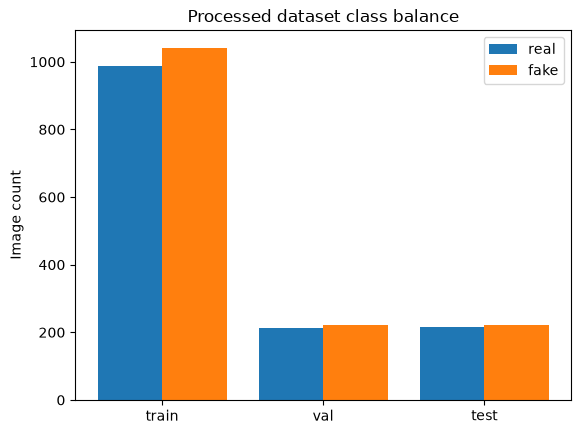

In [5]:
os.makedirs(PLOTS_DIR, exist_ok=True)
splits = list(counts.keys())
real_counts = [counts[s]['real'] for s in splits]
fake_counts = [counts[s]['fake'] for s in splits]

x = range(len(splits))
plt.figure()
plt.bar([i - 0.2 for i in x], real_counts, width=0.4, label='real')
plt.bar([i + 0.2 for i in x], fake_counts, width=0.4, label='fake')
plt.xticks(list(x), splits)
plt.ylabel('Image count')
plt.title('Processed dataset class balance')
plt.legend()
plt.savefig(os.path.join(PLOTS_DIR, 'class_balance.png'))
plt.show()

## What to verify yourself
- The assert above passed (images were found in `data/raw/rvf10k/valid`).
- `data/processed/train|val|test/real|fake` folders now contain images.
- The printed skip counts (no face detected) are a reasonable fraction of the sample, not most of it.
- `results/plots/class_balance.png` shows roughly balanced real/fake counts per split.